<a href="https://colab.research.google.com/github/JorgeMarquezPiedra/Contaminantes-en-la-Ciudad-de-Mexico-2015-a-2023-Python/blob/main/Contaminantes_CDMX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Red Manual de Monitoreo Atmosférico

In [1]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Leer dataset
redma = pd.read_csv('/content/redma_2023_05.csv')
redma

,fecha,PbPST,PM10,PM25,PST
0,2015-01-06,0.01645,37.625000,20.428571,97.500000
1,2015-01-12,0.02672,64.000000,33.285714,118.800000
2,2015-01-18,0.01704,48.750000,23.166667,99.200000
3,2015-01-24,0.01814,55.625000,24.166667,115.200000
4,2015-01-30,0.01896,56.750000,25.833333,127.400000
...,...,...,...,...,...
507,2023-05-06,NaN,63.142857,27.000000,140.000000
508,2023-05-12,NaN,49.571429,25.000000,116.000000
509,2023-05-18,NaN,42.600000,19.600000,91.500000
510,2023-05-24,NaN,46.142857,23.333333,92.666667


Partículas suspendidas totales (PST)

Partículas menores a 10 micrómetros (PM10)

Plomo en partículas suspendidas totales (Pb PST)

Partículas menores a 2.5 micrómetros (PM25)

In [3]:
# Pasar columna fecha a formato datetime, y crear columnas de año, mes, y día
redma['fecha'] = pd.to_datetime(redma['fecha'])
redma['año'] = redma['fecha'].dt.year
redma['mes'] = redma['fecha'].dt.month
redma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   512 non-null    datetime64[ns]
 1   PbPST   168 non-null    float64       
 2   PM10    495 non-null    float64       
 3   PM25    493 non-null    float64       
 4   PST     493 non-null    float64       
 5   año     512 non-null    int32         
 6   mes     512 non-null    int32         
dtypes: datetime64[ns](1), float64(4), int32(2)
memory usage: 24.1 KB


In [4]:
redma

,fecha,PbPST,PM10,PM25,PST,año,mes
0,2015-01-06,0.01645,37.625000,20.428571,97.500000,2015,1
1,2015-01-12,0.02672,64.000000,33.285714,118.800000,2015,1
2,2015-01-18,0.01704,48.750000,23.166667,99.200000,2015,1
3,2015-01-24,0.01814,55.625000,24.166667,115.200000,2015,1
4,2015-01-30,0.01896,56.750000,25.833333,127.400000,2015,1
...,...,...,...,...,...,...,...
507,2023-05-06,NaN,63.142857,27.000000,140.000000,2023,5
508,2023-05-12,NaN,49.571429,25.000000,116.000000,2023,5
509,2023-05-18,NaN,42.600000,19.600000,91.500000,2023,5
510,2023-05-24,NaN,46.142857,23.333333,92.666667,2023,5


In [5]:
# Corregir meses
# Mapear números de mes a nombres de mes
month_name_mapping = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre'
}

redma['mes'] = redma['mes'].map(month_name_mapping)
redma

,fecha,PbPST,PM10,PM25,PST,año,mes
0,2015-01-06,0.01645,37.625000,20.428571,97.500000,2015,Enero
1,2015-01-12,0.02672,64.000000,33.285714,118.800000,2015,Enero
2,2015-01-18,0.01704,48.750000,23.166667,99.200000,2015,Enero
3,2015-01-24,0.01814,55.625000,24.166667,115.200000,2015,Enero
4,2015-01-30,0.01896,56.750000,25.833333,127.400000,2015,Enero
...,...,...,...,...,...,...,...
507,2023-05-06,NaN,63.142857,27.000000,140.000000,2023,Mayo
508,2023-05-12,NaN,49.571429,25.000000,116.000000,2023,Mayo
509,2023-05-18,NaN,42.600000,19.600000,91.500000,2023,Mayo
510,2023-05-24,NaN,46.142857,23.333333,92.666667,2023,Mayo


In [6]:
# Crear días
# Mapear nombres de día en inglés a español
day_name_mapping_es = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

# Crear una nueva columna 'día_semana' con los nombres de los días en español
redma['dia'] = redma['fecha'].dt.day_name().map(day_name_mapping_es)
redma

,fecha,PbPST,PM10,PM25,PST,año,mes,dia
0,2015-01-06,0.01645,37.625000,20.428571,97.500000,2015,Enero,Martes
1,2015-01-12,0.02672,64.000000,33.285714,118.800000,2015,Enero,Lunes
2,2015-01-18,0.01704,48.750000,23.166667,99.200000,2015,Enero,Domingo
3,2015-01-24,0.01814,55.625000,24.166667,115.200000,2015,Enero,Sábado
4,2015-01-30,0.01896,56.750000,25.833333,127.400000,2015,Enero,Viernes
...,...,...,...,...,...,...,...,...
507,2023-05-06,NaN,63.142857,27.000000,140.000000,2023,Mayo,Sábado
508,2023-05-12,NaN,49.571429,25.000000,116.000000,2023,Mayo,Viernes
509,2023-05-18,NaN,42.600000,19.600000,91.500000,2023,Mayo,Jueves
510,2023-05-24,NaN,46.142857,23.333333,92.666667,2023,Mayo,Miércoles


In [7]:
# Información del dataset actualizada
redma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   512 non-null    datetime64[ns]
 1   PbPST   168 non-null    float64       
 2   PM10    495 non-null    float64       
 3   PM25    493 non-null    float64       
 4   PST     493 non-null    float64       
 5   año     512 non-null    int32         
 6   mes     512 non-null    object        
 7   dia     512 non-null    object        
dtypes: datetime64[ns](1), float64(4), int32(1), object(2)
memory usage: 30.1+ KB


In [8]:
# Estadísticas báscias
redma.describe()

,fecha,PbPST,PM10,PM25,PST,año
count,512,168.000000,495.000000,493.000000,493.000000,512.000000
mean,2019-03-19 00:00:00,0.021392,44.504957,20.327974,93.150436,2018.726562
min,2015-01-06 00:00:00,0.004220,7.333333,4.250000,18.000000,2015.000000
25%,2017-02-10 12:00:00,0.013000,31.437500,14.400000,66.000000,2017.000000
50%,2019-03-19 00:00:00,0.017020,42.500000,19.800000,89.400000,2019.000000
75%,2021-04-23 12:00:00,0.025385,57.125000,25.166667,118.000000,2021.000000
max,2023-05-30 00:00:00,0.118240,103.833333,80.333333,243.000000,2023.000000
std,NaN,0.015359,17.711722,8.736546,35.118339,2.434954


##Histogramas

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

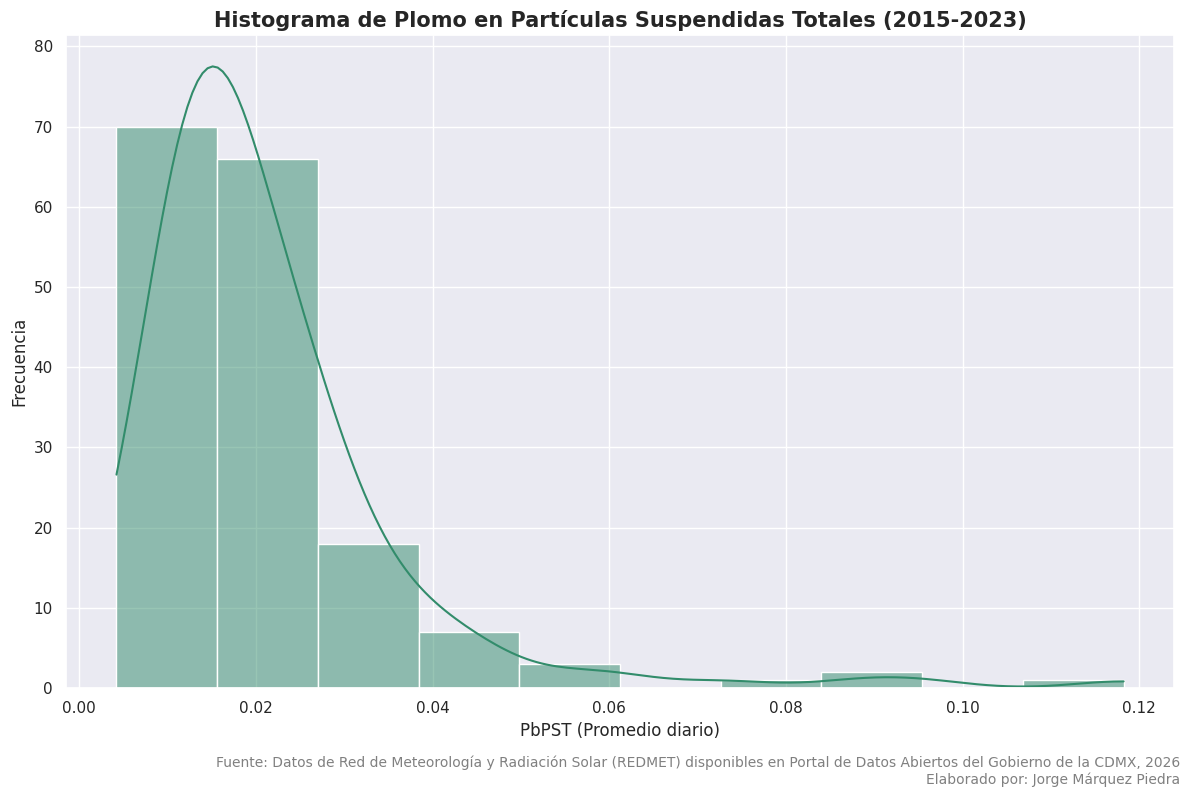

In [9]:
# Histograma de PbPST
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(redma['PbPST'], bins = 10, kde = True, color = '#328c6b')
plt.title('Histograma de Plomo en Partículas Suspendidas Totales (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel('PbPST (Promedio diario)')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_pbpst.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

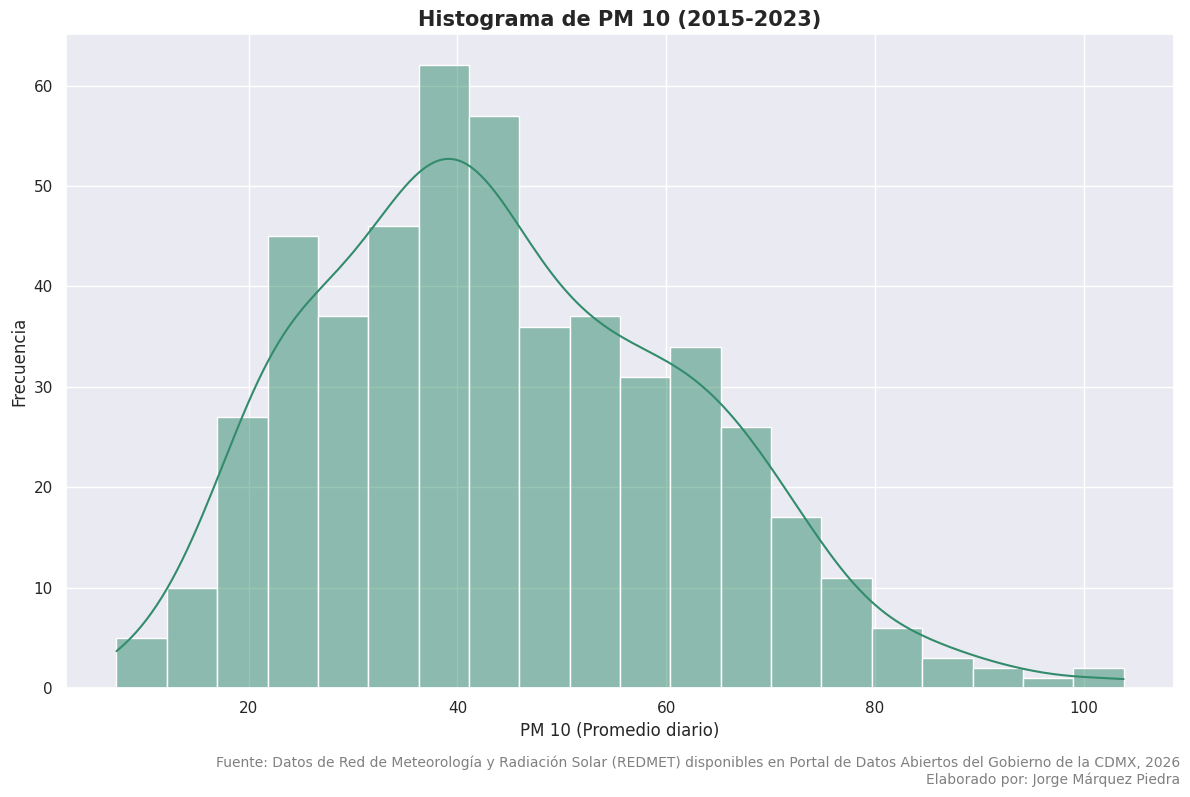

In [10]:
# Histograma de PM10
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(redma['PM10'], bins = 20, kde = True, color = '#328c6b')
plt.title('Histograma de PM 10 (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel('PM 10 (Promedio diario)')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_pm10.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

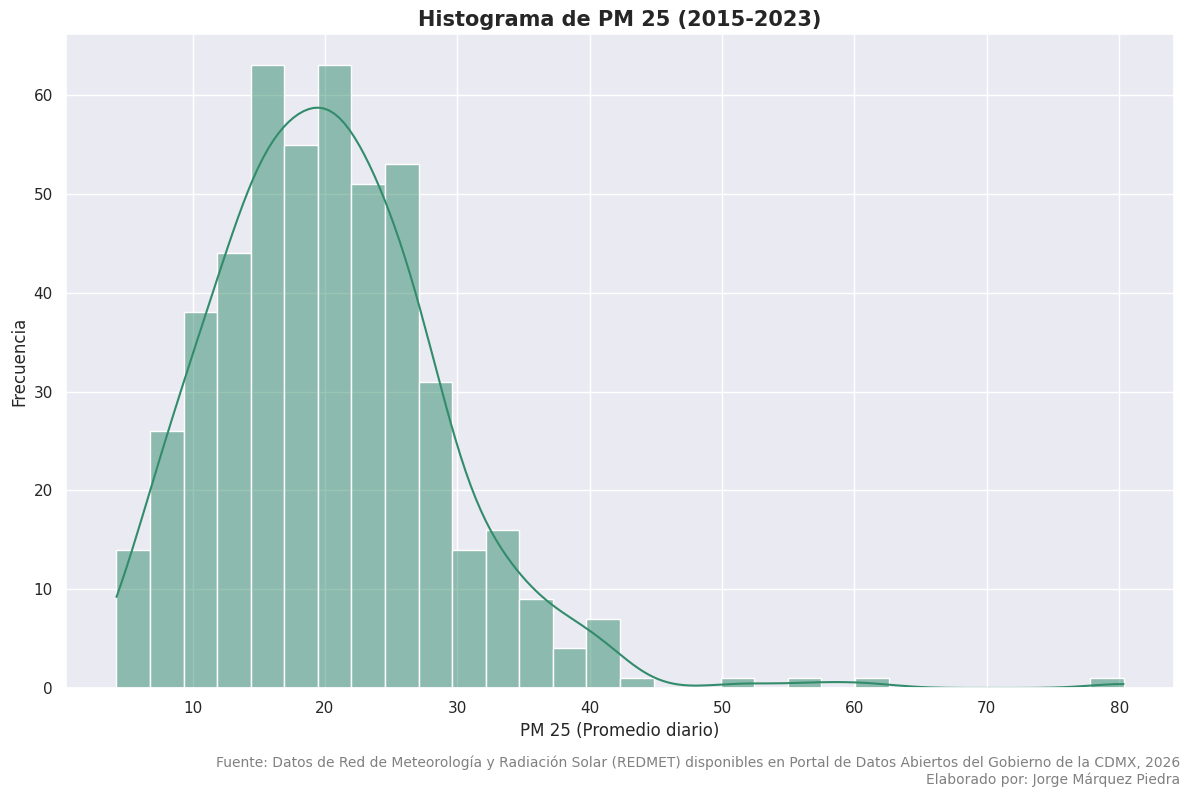

In [11]:
# Histograma de PM25
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(redma['PM25'], bins = 30, kde = True, color = '#328c6b')
plt.title('Histograma de PM 25 (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel('PM 25 (Promedio diario)')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_pm25.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

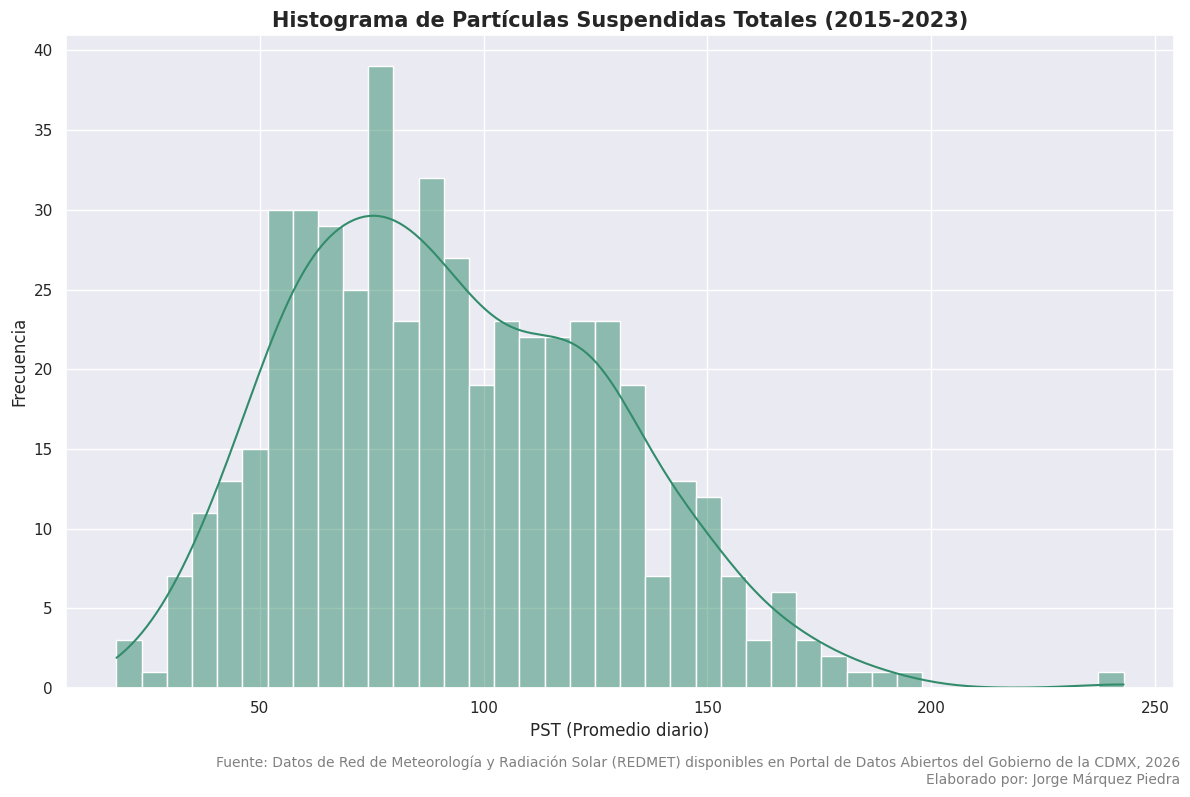

In [12]:
# Histograma de PST
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(redma['PST'], bins = 40, kde = True, color = '#328c6b')
plt.title('Histograma de Partículas Suspendidas Totales (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel('PST (Promedio diario)')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_pst.png', dpi = 300)
plt

##Tendencia temporal de las PM25

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

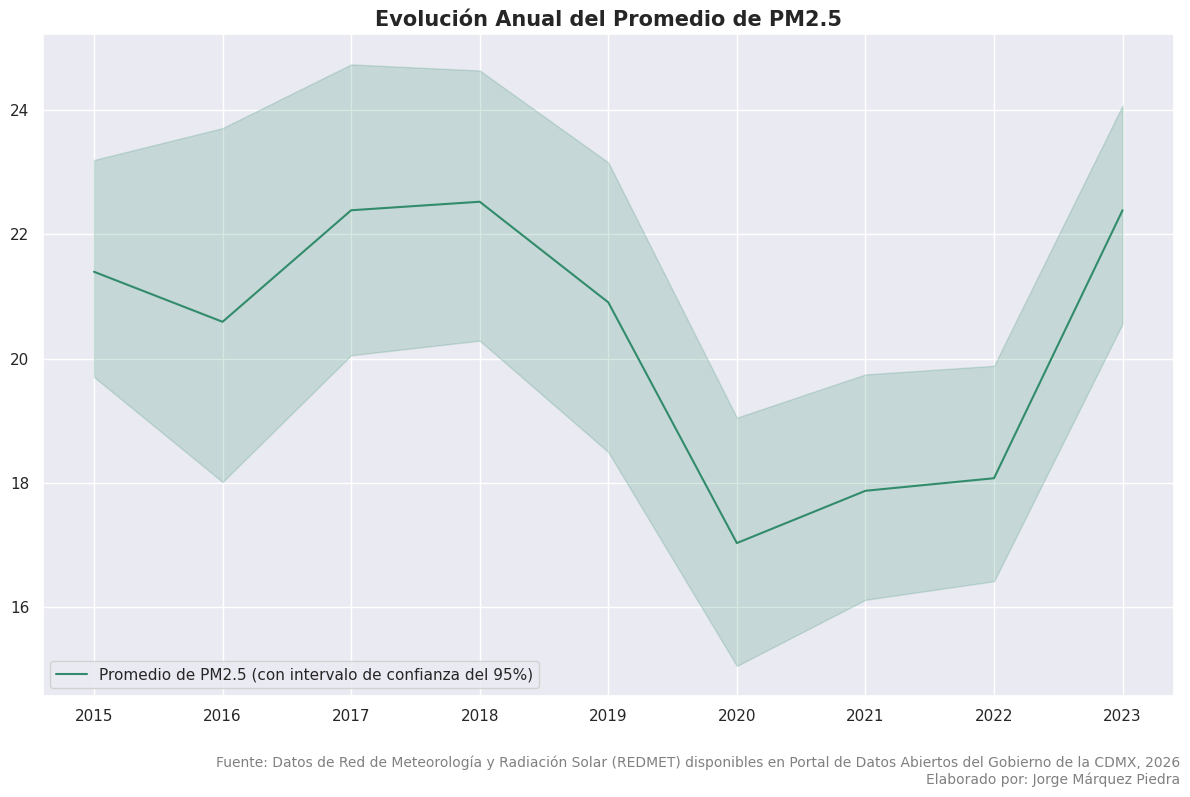

In [25]:
plt.figure(figsize=(12,8))
sns.set_theme()
sns.lineplot(data = redma, x = 'año', y = 'PM25', color = '#328c6b', label = 'Promedio de PM2.5 (con intervalo de confianza del 95%)')
plt.title('Evolución Anual del Promedio de PM2.5', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(redma['año'].unique())
plt.legend(loc = 'lower left')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('evolucion_temporal_pm25.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

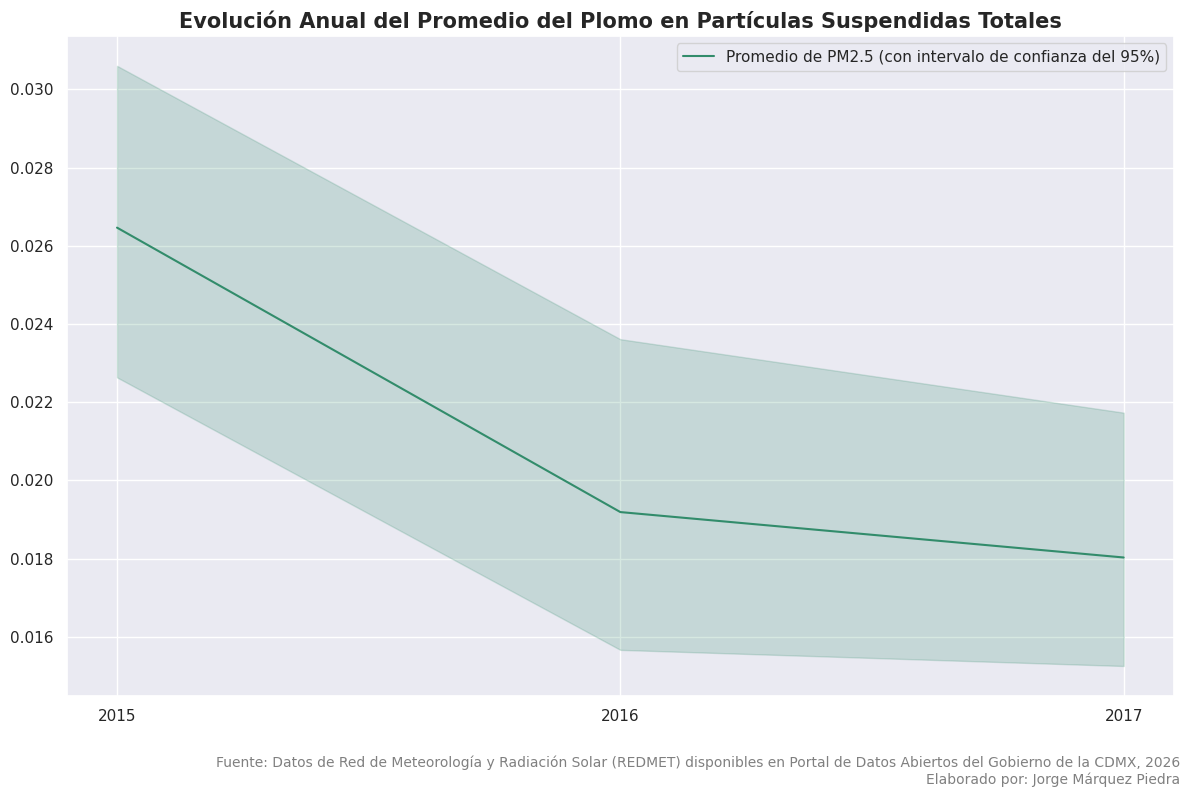

In [30]:
plt.figure(figsize=(12,8))
sns.set_theme()
sns.lineplot(data = redma, x = 'año', y = 'PbPST', color = '#328c6b', label='Promedio de PM2.5 (con intervalo de confianza del 95%)')
plt.title('Evolución Anual del Promedio del Plomo en Partículas Suspendidas Totales', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks([2015, 2016, 2017])
plt.legend(loc = 'upper right')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('evolucion_temporal_pbpst.png', dpi = 300)
plt

##Promedio mensual

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

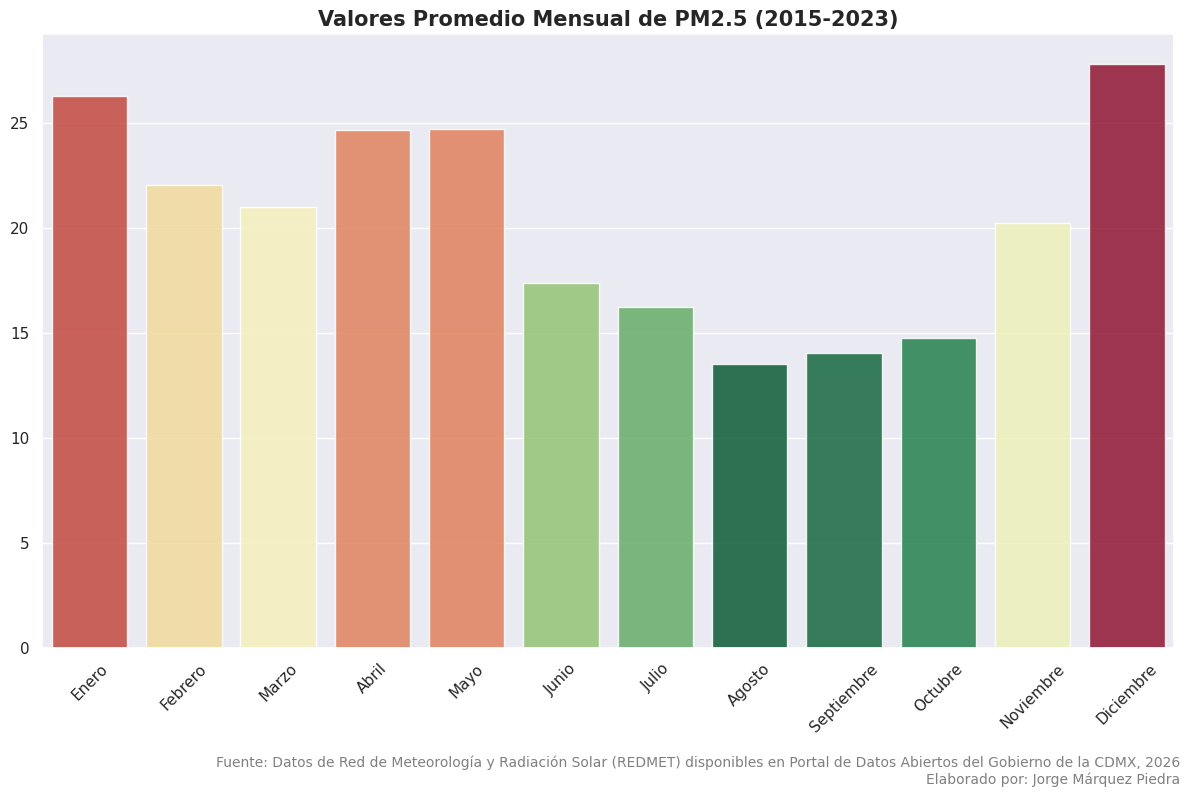

In [15]:
# Crear dataframe mensual
promedio_mes = redma.groupby('mes')[['PM25','PM10','PST']].mean().reset_index()

# Definir el orden correcto de dias
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Ordenar el dataframe usando el orden de meses
promedio_mes['mes'] = pd.Categorical(promedio_mes['mes'], categories = orden_meses, ordered = True)
promedio_mes = promedio_mes.sort_values('mes')

plt.figure(figsize = (12,8))
sns.barplot(data = promedio_mes, x = 'mes', y = 'PM25', hue = 'PM25', palette = 'RdYlGn_r', alpha = 0.85, legend = False)
plt.title('Valores Promedio Mensual de PM2.5 (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('promedio_por_mes_pm25.png', dpi = 300)
plt

##Variabilidad de contaminación  por mes

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

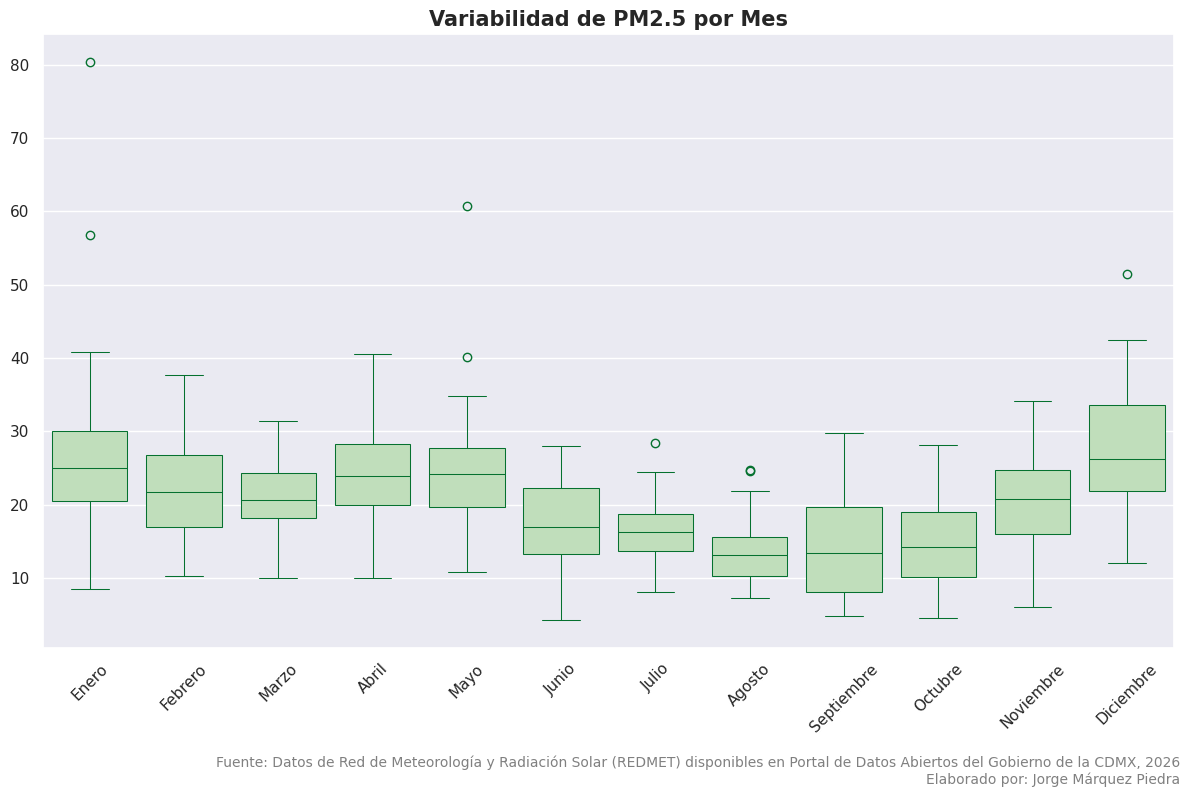

In [16]:
plt.figure(figsize = (12,8))
sns.boxplot(data = redma, x = 'mes', y = 'PM25', color = '#bce4b5', linecolor="#05712f", linewidth=.75)
plt.xticks(rotation = 45)
plt.title('Variabilidad de PM2.5 por Mes', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('boxplot_por_mes_pm25.png', dpi = 300)
plt


##Correlación de variables

In [17]:
# Matriz de correlación
correlation_matrix = redma[['PM25','PM10','PST','PbPST']].corr()
print("Matriz de correlación:")
print(correlation_matrix)

Matriz de correlación:
           PM25      PM10       PST     PbPST
PM25   1.000000  0.847856  0.695086  0.616754
PM10   0.847856  1.000000  0.931475  0.517505
PST    0.695086  0.931475  1.000000  0.488185
PbPST  0.616754  0.517505  0.488185  1.000000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

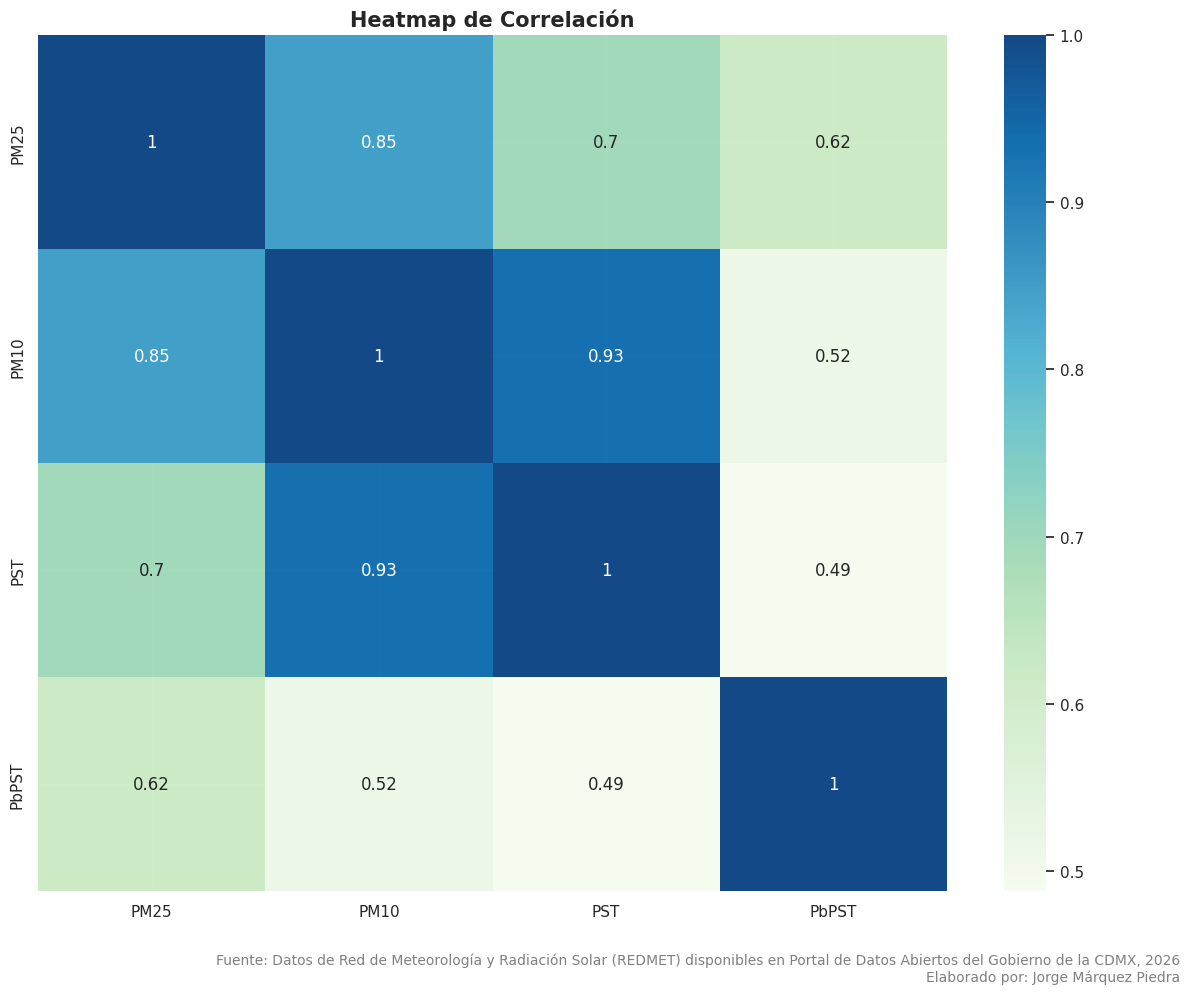

In [18]:
# Generar Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='GnBu', alpha = 0.95)
plt.title('Heatmap de Correlación', fontsize = 15, fontweight = 'bold')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.10)
plt.savefig('matriz_correlacion.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

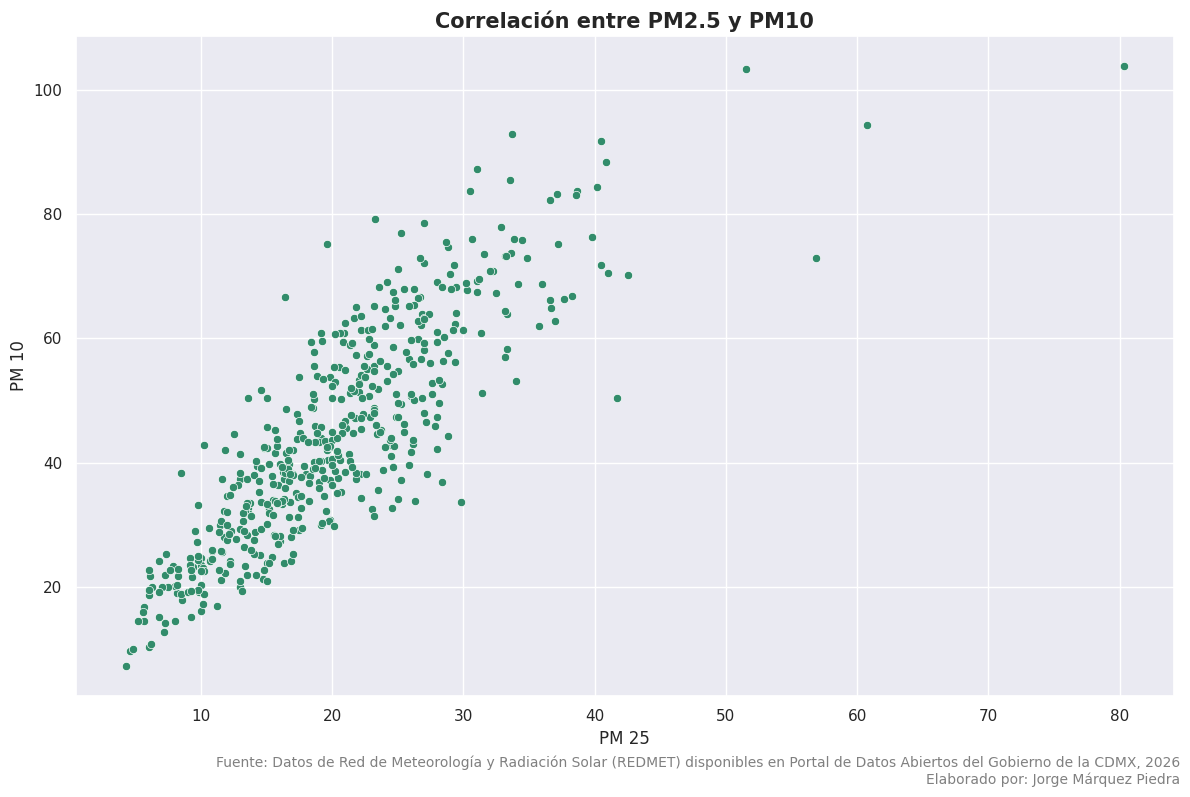

In [19]:
# Gráficos de correlación PM25 y PM10
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.scatterplot(data = redma, x = 'PM25', y = 'PM10', color = '#328c6b')
plt.title('Correlación entre PM2.5 y PM10', fontsize = 15, fontweight = 'bold')
plt.xlabel('PM 25')
plt.ylabel('PM 10')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('scatterplot_pm25_pm10.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

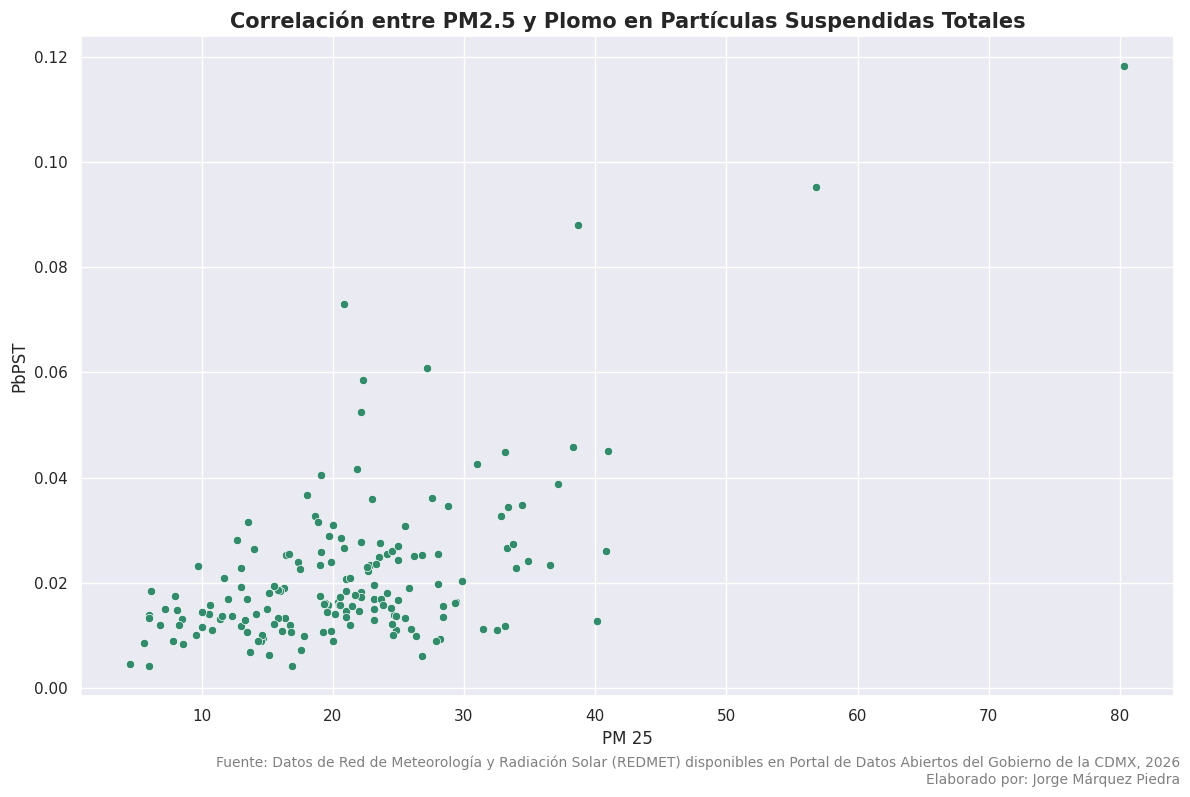

In [20]:
# Gráficos de correlación PM25 y PbPST
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.scatterplot(data = redma, x = 'PM25', y = 'PbPST', color = '#328c6b')
plt.title('Correlación entre PM2.5 y Plomo en Partículas Suspendidas Totales', fontsize = 15, fontweight = 'bold')
plt.xlabel('PM 25')
plt.ylabel('PbPST')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('scatterplot_pm25_pbpst.png', dpi = 300)
plt

##Valores extremos

In [21]:
q1 = redma['PM25'].quantile(0.25)
q3 = redma['PM25'].quantile(0.75)
iqr = q3 - q1

redma_extremos = redma[redma['PM25'] > q3 + 1.5*iqr]
redma_extremos

,fecha,PbPST,PM10,PM25,PST,año,mes,dia
60,2016-01-01,0.11824,103.833333,80.333333,149.400000,2016,Enero,Viernes
121,2017-01-01,0.09520,73.000000,56.833333,107.200000,2017,Enero,Domingo
177,2017-12-03,NaN,70.125000,42.500000,110.600000,2017,Diciembre,Domingo
241,2018-12-22,NaN,103.375000,51.500000,243.000000,2018,Diciembre,Sábado
265,2019-05-15,NaN,94.400000,60.750000,151.500000,2019,Mayo,Miércoles
485,2022-12-25,NaN,50.428571,41.666667,67.333333,2022,Diciembre,Domingo


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

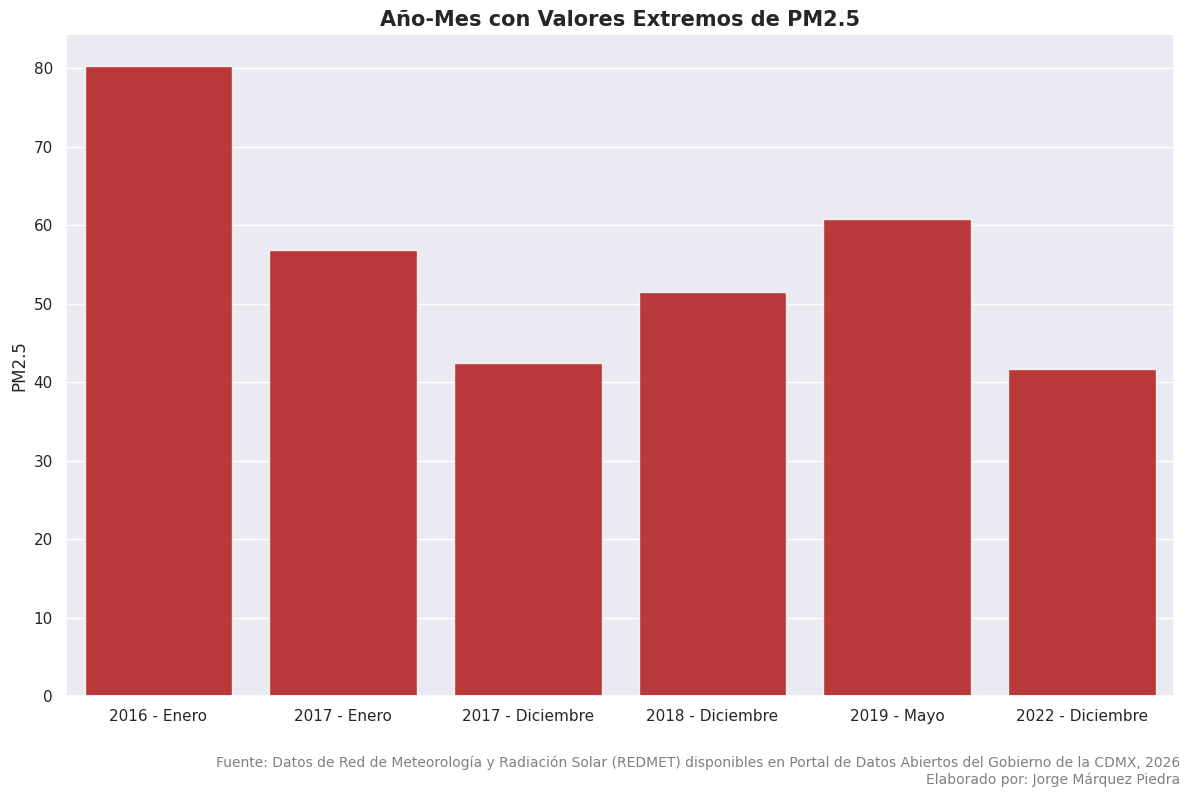

In [23]:
redma_extremos = redma_extremos.copy()
redma_extremos['Año-Mes'] = redma_extremos['año'].astype(str) + ' - ' + redma_extremos['mes']

plt.figure(figsize = (12, 8))
sns.barplot(data = redma_extremos.sort_values(by = 'fecha'), x = 'Año-Mes', y = 'PM25', color = '#ca0000', alpha = 0.85)
plt.title('Año-Mes con Valores Extremos de PM2.5', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('PM2.5')
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('valores_extremos_pm25.png', dpi = 300)
plt